# CESM2 / ISMIP7 Forcing File Walkthrough

This notebook explores the NetCDF file `tas_AIS_CESM2-WACCM_ssp126_SDBN1_v2_2015.nc` and makes a small set of polished summary figures.

## What this file appears to be

- `tas` is **near-surface air temperature** (`standard_name = air_temperature`)
- Units are **Kelvin**
- The file contains **12 monthly slices for 2015**
- The grid is an Antarctic **polar stereographic projection** (`EPSG:3031`)
- Coordinates are stored as projected `x` and `y` axes in **meters**

In other words: this is a monthly atmospheric forcing field over Antarctica, prepared for ISMIP7 and regridded onto the ISMIP grid.


In [1]:
from __future__ import annotations

from datetime import datetime, timedelta
from pathlib import Path

import h5py
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


DATA_PATH = Path("tas_AIS_CESM2-WACCM_ssp126_SDBN1_v2_2015.nc")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def _decode(value):
    if isinstance(value, bytes):
        return value.decode("utf-8")
    if isinstance(value, np.ndarray) and value.shape == (1,):
        return _decode(value[0])
    return value


mpl.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 140,
        "savefig.dpi": 220,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.facecolor": "#f7f6f2",
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "grid.color": "#d8d5cc",
        "grid.alpha": 0.6,
        "font.size": 11,
    }
)


In [2]:
with h5py.File(DATA_PATH, "r") as f:
    variable_names = list(f.keys())
    attrs = {k: _decode(v) for k, v in f.attrs.items()}
    tas_attrs = {k: _decode(v) for k, v in f["tas"].attrs.items()}
    time_attrs = {k: _decode(v) for k, v in f["time"].attrs.items()}
    x = f["x"][:]
    y = f["y"][:]
    time_raw = f["time"][:]

base_time = datetime(1850, 1, 1)
time = np.array([base_time + timedelta(days=int(day)) for day in time_raw])
month_labels = [t.strftime("%b") for t in time]

print("Variables:", variable_names)
print()
print("Global metadata:")
for key in ["title", "institution", "source", "comment", "grid", "Conventions"]:
    if key in attrs:
        print(f"  {key}: {attrs[key]}")
print()
print("tas metadata:")
for key, value in tas_attrs.items():
    print(f"  {key}: {value}")
print()
print(f"Grid shape: time={len(time)}, y={len(y)}, x={len(x)}")
print(f"x extent: {x.min()/1000:.0f} to {x.max()/1000:.0f} km")
print(f"y extent: {y.min()/1000:.0f} to {y.max()/1000:.0f} km")
print("Time stamps:", [t.strftime("%Y-%m-%d") for t in time])


Variables: ['tas', 'time', 'y', 'x']

Global metadata:
  title: tas regridded onto ISMIP grid
  institution: ULiege (Brice Noel)
  source: SDBN1 - Brice Noel -  bnoel@uliege.be
  comment: Prepared for ISMIP7 by Devon Dunmire using xesmf ddunmire@buffalo.edu
  grid: Map Projection: Polar Stereographic South EPSG3031 - Map Reference Latitude: -71.0 - Map Reference Longitude: 0.0
  Conventions: CF-1.6

tas metadata:
  _Netcdf4Coordinates: [0 1 2]
  _FillValue: 9.969209968386869e+36
  units: K
  standard_name: air_temperature
  long_name: Near-Surface Air Temperature
  missing_value: 9.969209968386869e+36
  DIMENSION_LIST: [array([<HDF5 object reference>], dtype=object)
 array([<HDF5 object reference>], dtype=object)
 array([<HDF5 object reference>], dtype=object)]
  _Netcdf4Dimid: 0

Grid shape: time=12, y=3041, x=3041
x extent: -3040 to 3040 km
y extent: -3040 to 3040 km
Time stamps: ['2015-01-15', '2015-02-15', '2015-03-15', '2015-04-15', '2015-05-15', '2015-06-15', '2015-07-15', '2015-

## Reading helpers

The file uses a large numeric fill value (`9.96921e36`) instead of NaNs, so the first step is to mask those cells.

To keep the plotting lightweight, the mapping routines below also support downsampling with a stride.


In [3]:
with h5py.File(DATA_PATH, "r") as f:
    fill_value = float(np.array(f["tas"].attrs["_FillValue"]).ravel()[0])


def read_tas(month_index: int, stride: int = 1) -> np.ndarray:
    with h5py.File(DATA_PATH, "r") as f:
        arr = f["tas"][month_index, ::stride, ::stride].astype(np.float64)
    arr[arr >= fill_value * 0.1] = np.nan
    return arr


def nanmean_stack(arr: np.ndarray, axis: int = 0) -> np.ndarray:
    valid = np.isfinite(arr)
    counts = valid.sum(axis=axis)
    total = np.where(valid, arr, 0.0).sum(axis=axis)
    out = np.full(total.shape, np.nan, dtype=np.float64)
    np.divide(total, counts, out=out, where=counts > 0)
    return out


def nanstd_stack(arr: np.ndarray, axis: int = 0) -> np.ndarray:
    mean = nanmean_stack(arr, axis=axis)
    expanded_mean = np.expand_dims(mean, axis=axis)
    valid = np.isfinite(arr)
    sq = np.where(valid, (arr - expanded_mean) ** 2, 0.0)
    counts = valid.sum(axis=axis)
    out = np.full(mean.shape, np.nan, dtype=np.float64)
    np.divide(sq.sum(axis=axis), counts, out=out, where=counts > 0)
    return np.sqrt(out)


def compute_monthly_statistics() -> dict[str, np.ndarray]:
    means = []
    stds = []
    mins = []
    maxs = []
    valid_fraction = []

    with h5py.File(DATA_PATH, "r") as f:
        for i in range(f["tas"].shape[0]):
            arr = f["tas"][i].astype(np.float64)
            arr[arr >= fill_value * 0.1] = np.nan
            finite = np.isfinite(arr)
            valid_fraction.append(finite.mean())
            means.append(np.nanmean(arr))
            stds.append(np.nanstd(arr))
            mins.append(np.nanmin(arr))
            maxs.append(np.nanmax(arr))

    return {
        "mean": np.array(means),
        "std": np.array(stds),
        "min": np.array(mins),
        "max": np.array(maxs),
        "valid_fraction": np.array(valid_fraction),
    }


stats = compute_monthly_statistics()
stats


{'mean': array([257.74233893, 250.35988766, 242.58115215, 235.85466758,
        236.71811214, 231.92065105, 232.47379084, 232.83199348,
        231.92119938, 237.92082797, 248.90868943, 256.45422573]),
 'std': array([10.33824031, 12.9717247 , 13.75502074, 14.24448984, 13.29956665,
        13.92223653, 13.49125936, 14.76520156, 13.9609811 , 12.46711755,
        10.77484296, 10.09187295]),
 'min': array([235.42114258, 223.41970825, 213.80760193, 206.09274292,
        210.11529541, 201.55638123, 201.04814148, 199.13418579,
        204.18563843, 210.70201111, 225.14961243, 234.47825623]),
 'max': array([275.68457031, 276.48120117, 274.69186401, 271.8230896 ,
        267.69763184, 267.14215088, 266.65704346, 264.62597656,
        265.92428589, 270.18035889, 271.83300781, 274.32733154]),
 'valid_fraction': array([0.42270316, 0.42270316, 0.42270316, 0.42270316, 0.42270316,
        0.42270316, 0.42270316, 0.42270316, 0.42270316, 0.42270316,
        0.42270316, 0.42270316])}

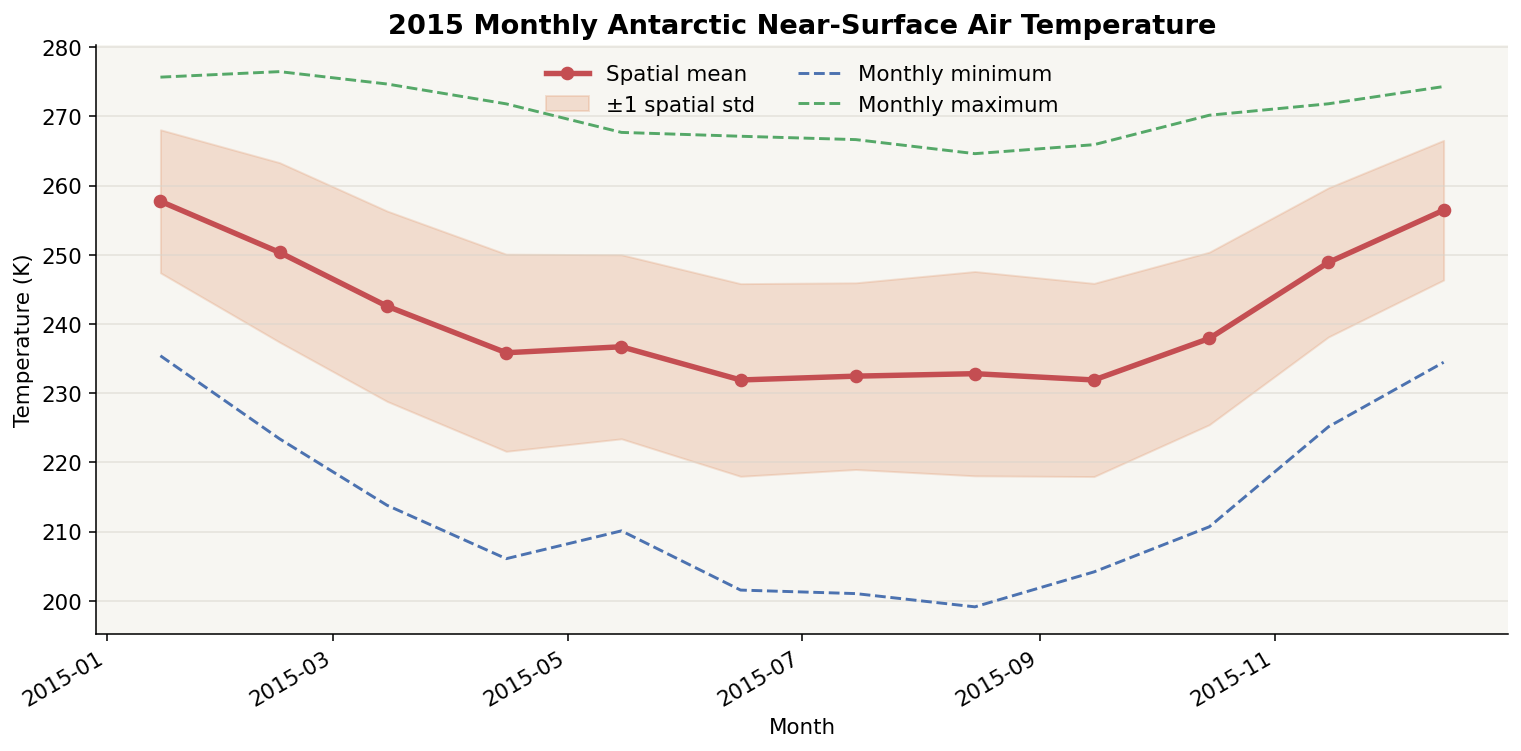

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(time, stats["mean"], color="#c44e52", lw=2.8, marker="o", label="Spatial mean")
ax.fill_between(
    time,
    stats["mean"] - stats["std"],
    stats["mean"] + stats["std"],
    color="#dd8452",
    alpha=0.22,
    label="±1 spatial std",
)
ax.plot(time, stats["min"], color="#4c72b0", lw=1.5, ls="--", label="Monthly minimum")
ax.plot(time, stats["max"], color="#55a868", lw=1.5, ls="--", label="Monthly maximum")

ax.set_title("2015 Monthly Antarctic Near-Surface Air Temperature")
ax.set_ylabel("Temperature (K)")
ax.set_xlabel("Month")
ax.grid(True, axis="y")
ax.legend(frameon=False, ncol=2)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / "tas_monthly_statistics.png", bbox_inches="tight")
plt.show()


## Spatial maps

The domain is shown in projected Antarctic coordinates, with axes in kilometers relative to the pole-centered stereographic grid.


In [5]:
stride = 4
maps = np.stack([read_tas(i, stride=stride) for i in range(len(time))])
x_km = x[::stride] / 1000.0
y_km = y[::stride] / 1000.0
extent = [x_km.min(), x_km.max(), y_km.min(), y_km.max()]

robust_vmin = np.nanpercentile(maps, 2)
robust_vmax = np.nanpercentile(maps, 98)
annual_mean_map = nanmean_stack(maps, axis=0)
annual_std_map = nanstd_stack(maps, axis=0)

robust_vmin, robust_vmax


(np.float64(211.34994750976563), np.float64(271.05562255859377))

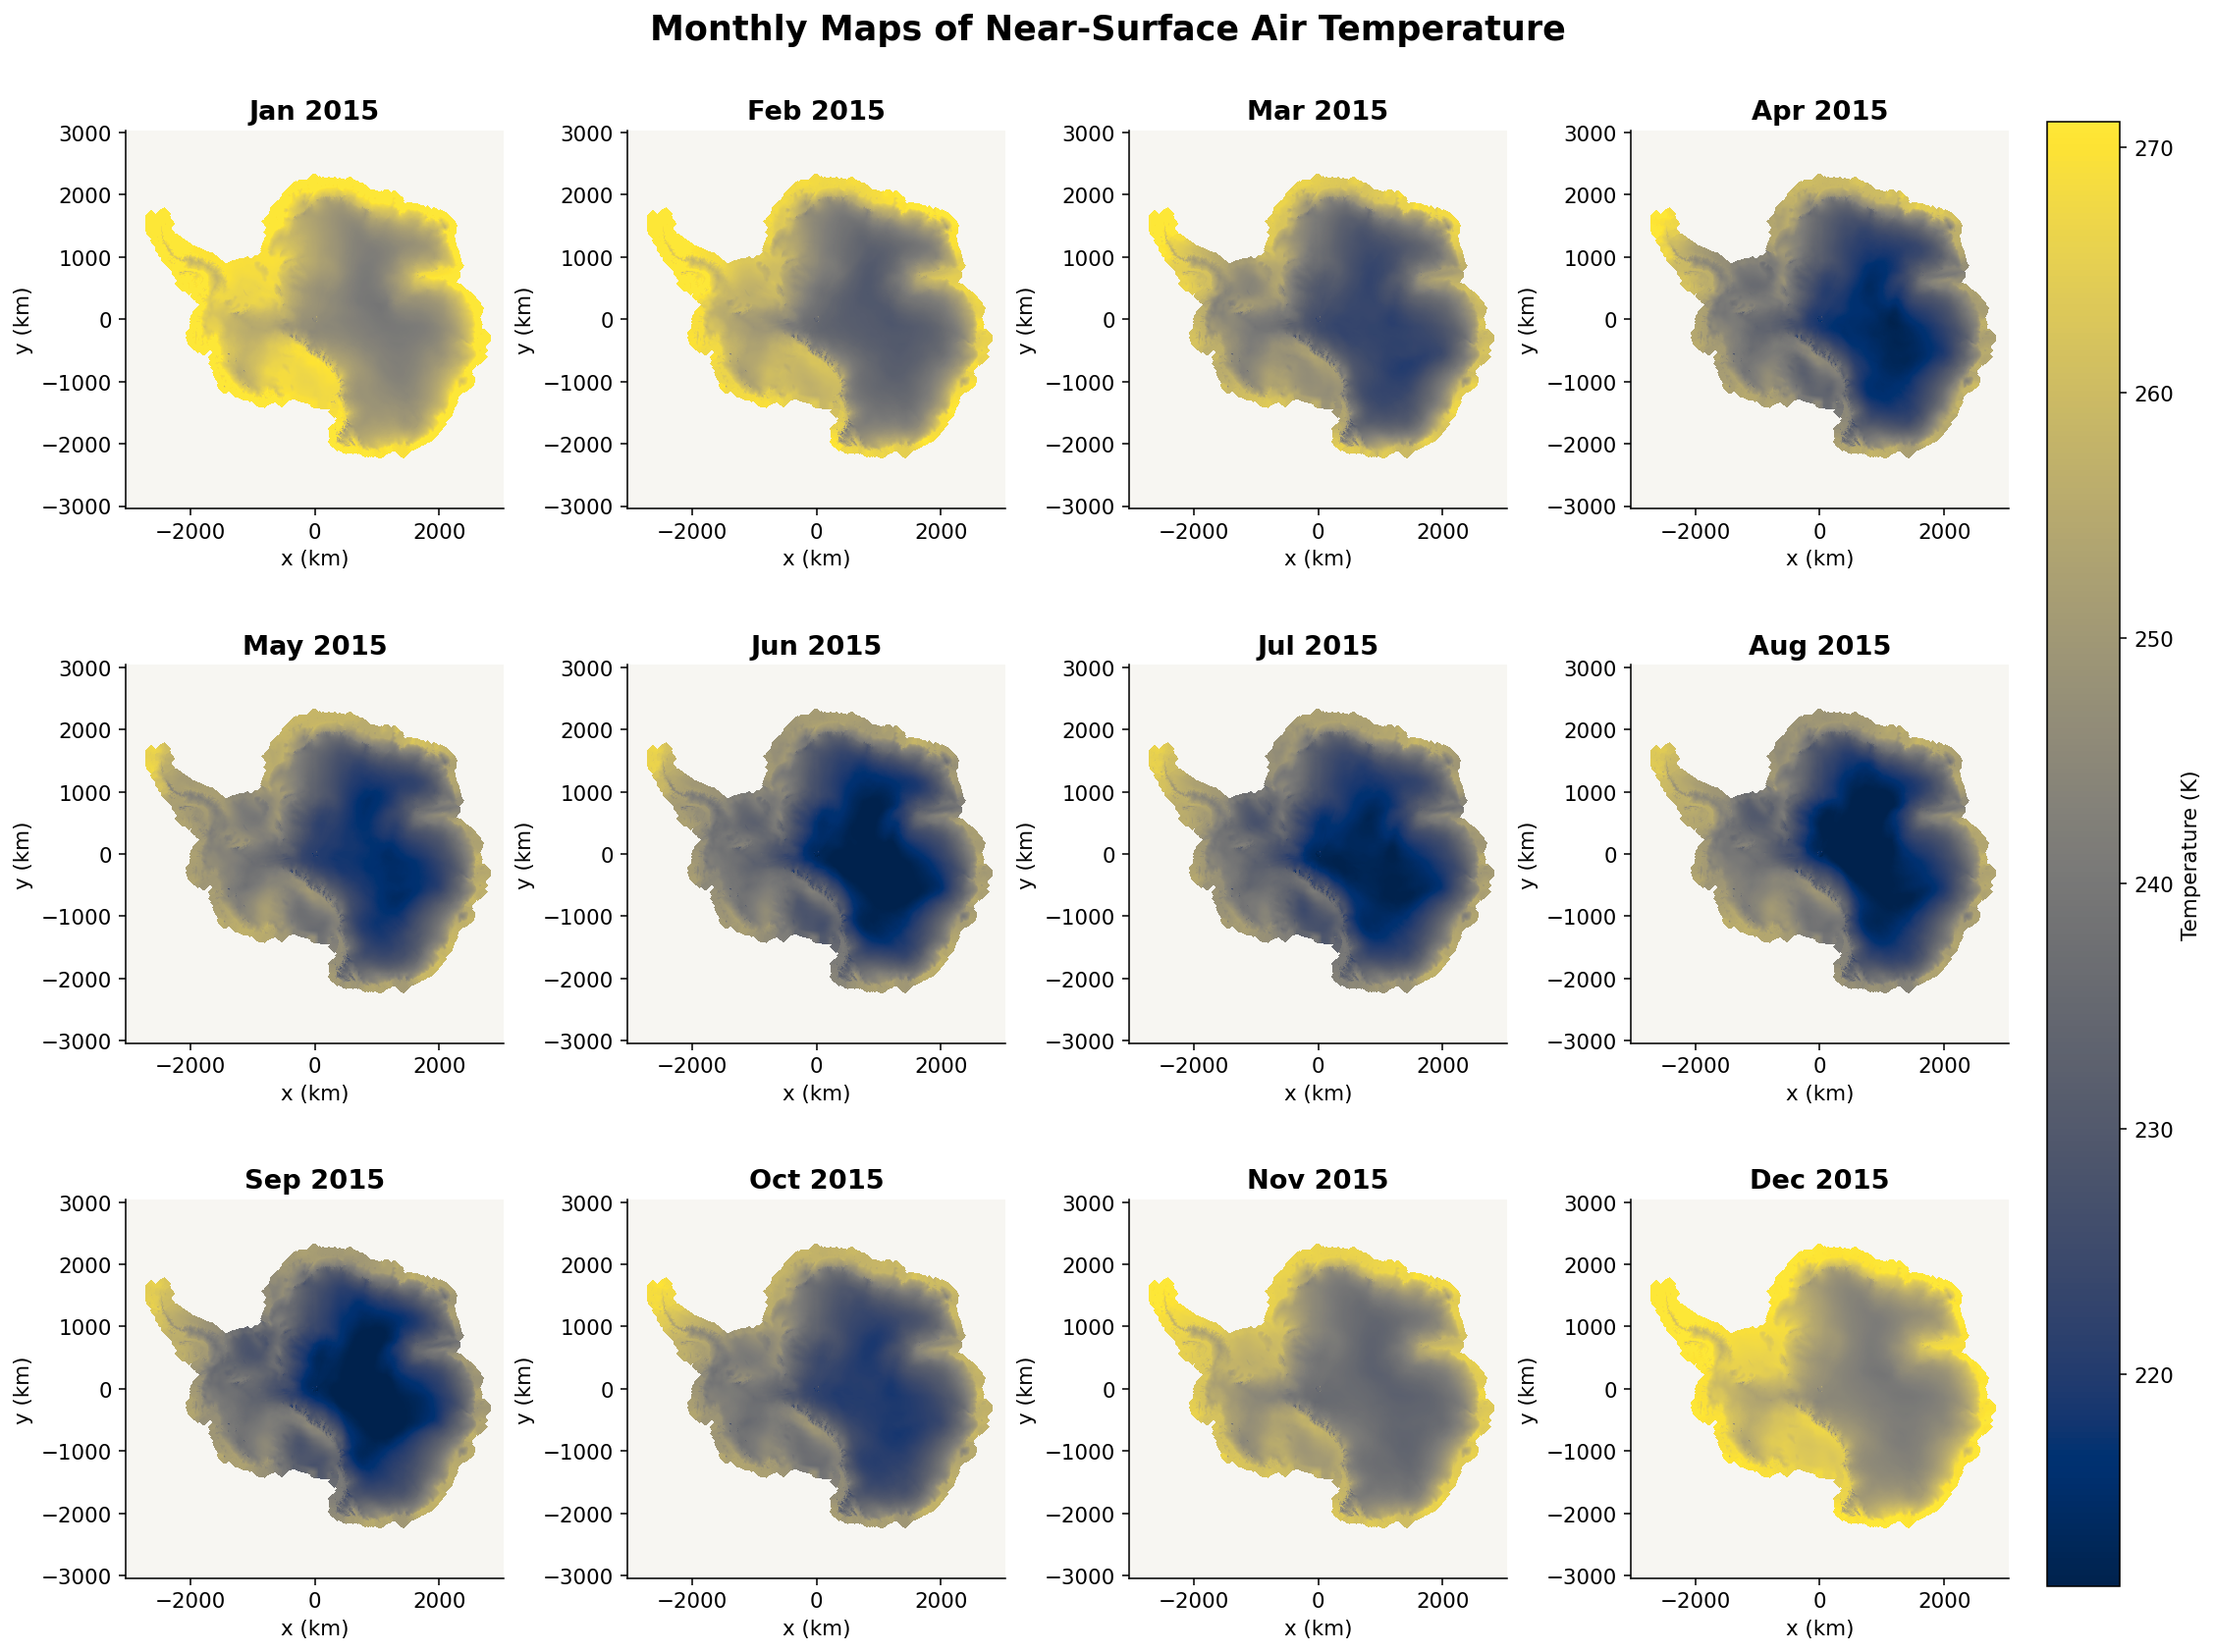

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12), constrained_layout=True)

for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(
        maps[i],
        origin="lower",
        extent=extent,
        cmap="cividis",
        vmin=robust_vmin,
        vmax=robust_vmax,
        interpolation="nearest",
    )
    ax.set_title(time[i].strftime("%b %Y"))
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")

cbar = fig.colorbar(im, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label("Temperature (K)")
fig.suptitle("Monthly Maps of Near-Surface Air Temperature", fontsize=18, fontweight="bold")
fig.savefig(FIG_DIR / "tas_monthly_maps.png", bbox_inches="tight")
plt.show()


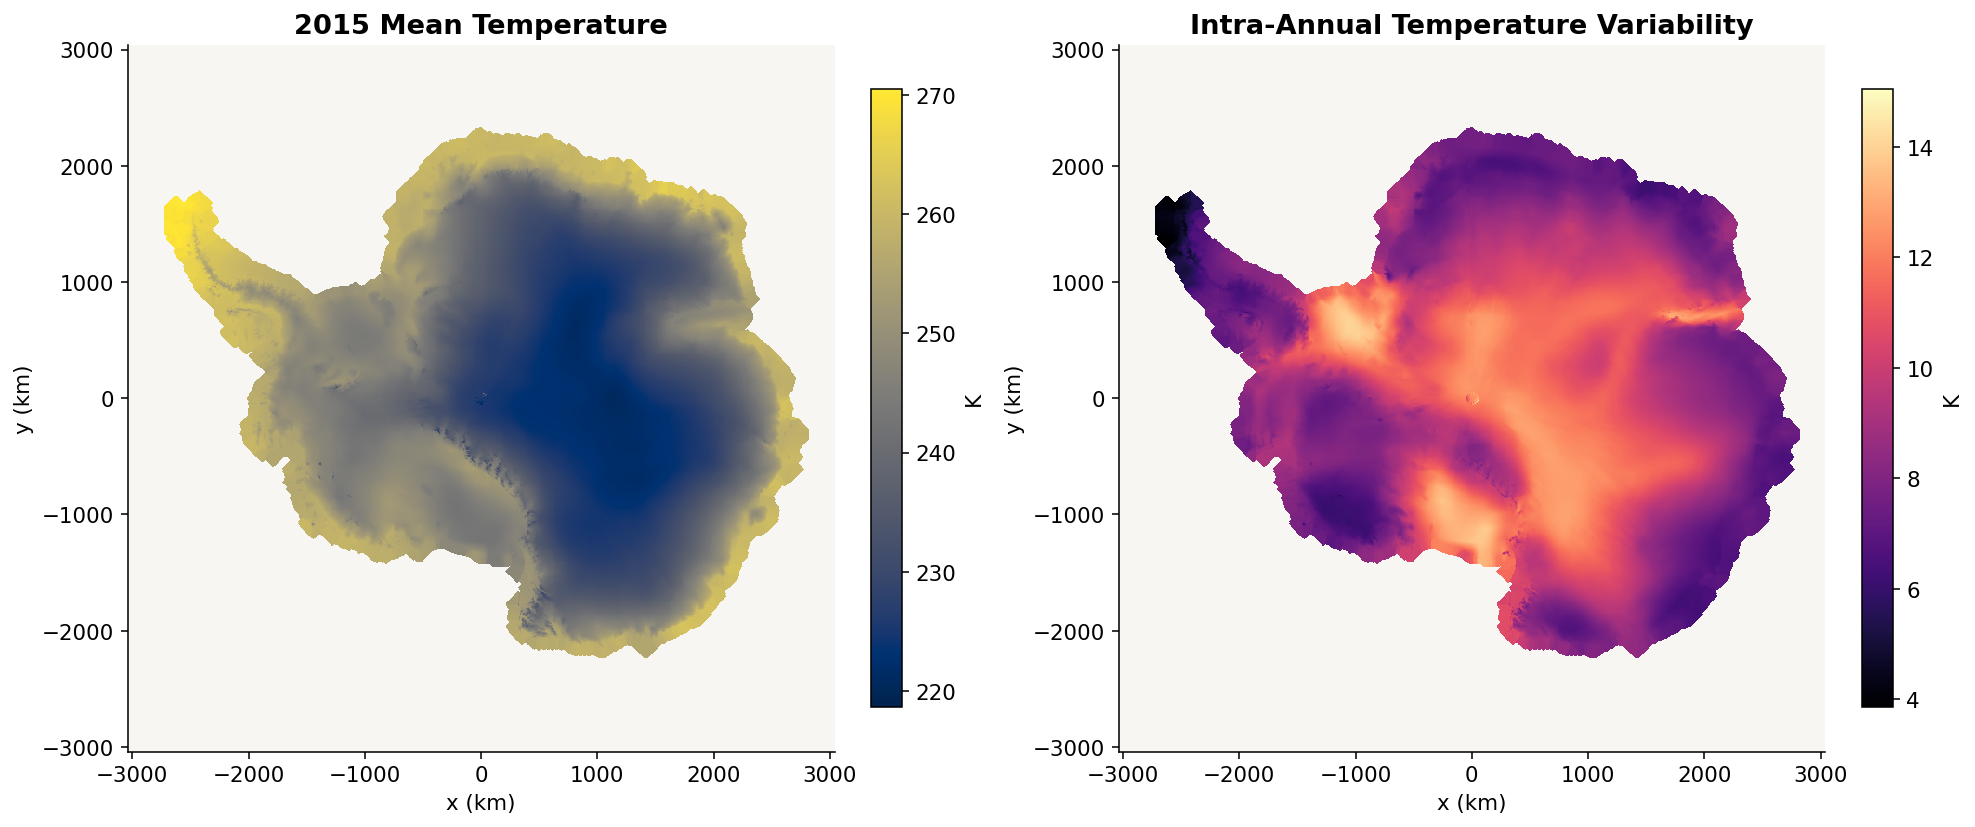

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)

im0 = axes[0].imshow(
    annual_mean_map,
    origin="lower",
    extent=extent,
    cmap="cividis",
    interpolation="nearest",
)
axes[0].set_title("2015 Mean Temperature")
axes[0].set_xlabel("x (km)")
axes[0].set_ylabel("y (km)")

im1 = axes[1].imshow(
    annual_std_map,
    origin="lower",
    extent=extent,
    cmap="magma",
    interpolation="nearest",
)
axes[1].set_title("Intra-Annual Temperature Variability")
axes[1].set_xlabel("x (km)")
axes[1].set_ylabel("y (km)")

cbar0 = fig.colorbar(im0, ax=axes[0], shrink=0.85, pad=0.02)
cbar0.set_label("K")
cbar1 = fig.colorbar(im1, ax=axes[1], shrink=0.85, pad=0.02)
cbar1.set_label("K")

fig.savefig(FIG_DIR / "tas_annual_mean_and_variability.png", bbox_inches="tight")
plt.show()


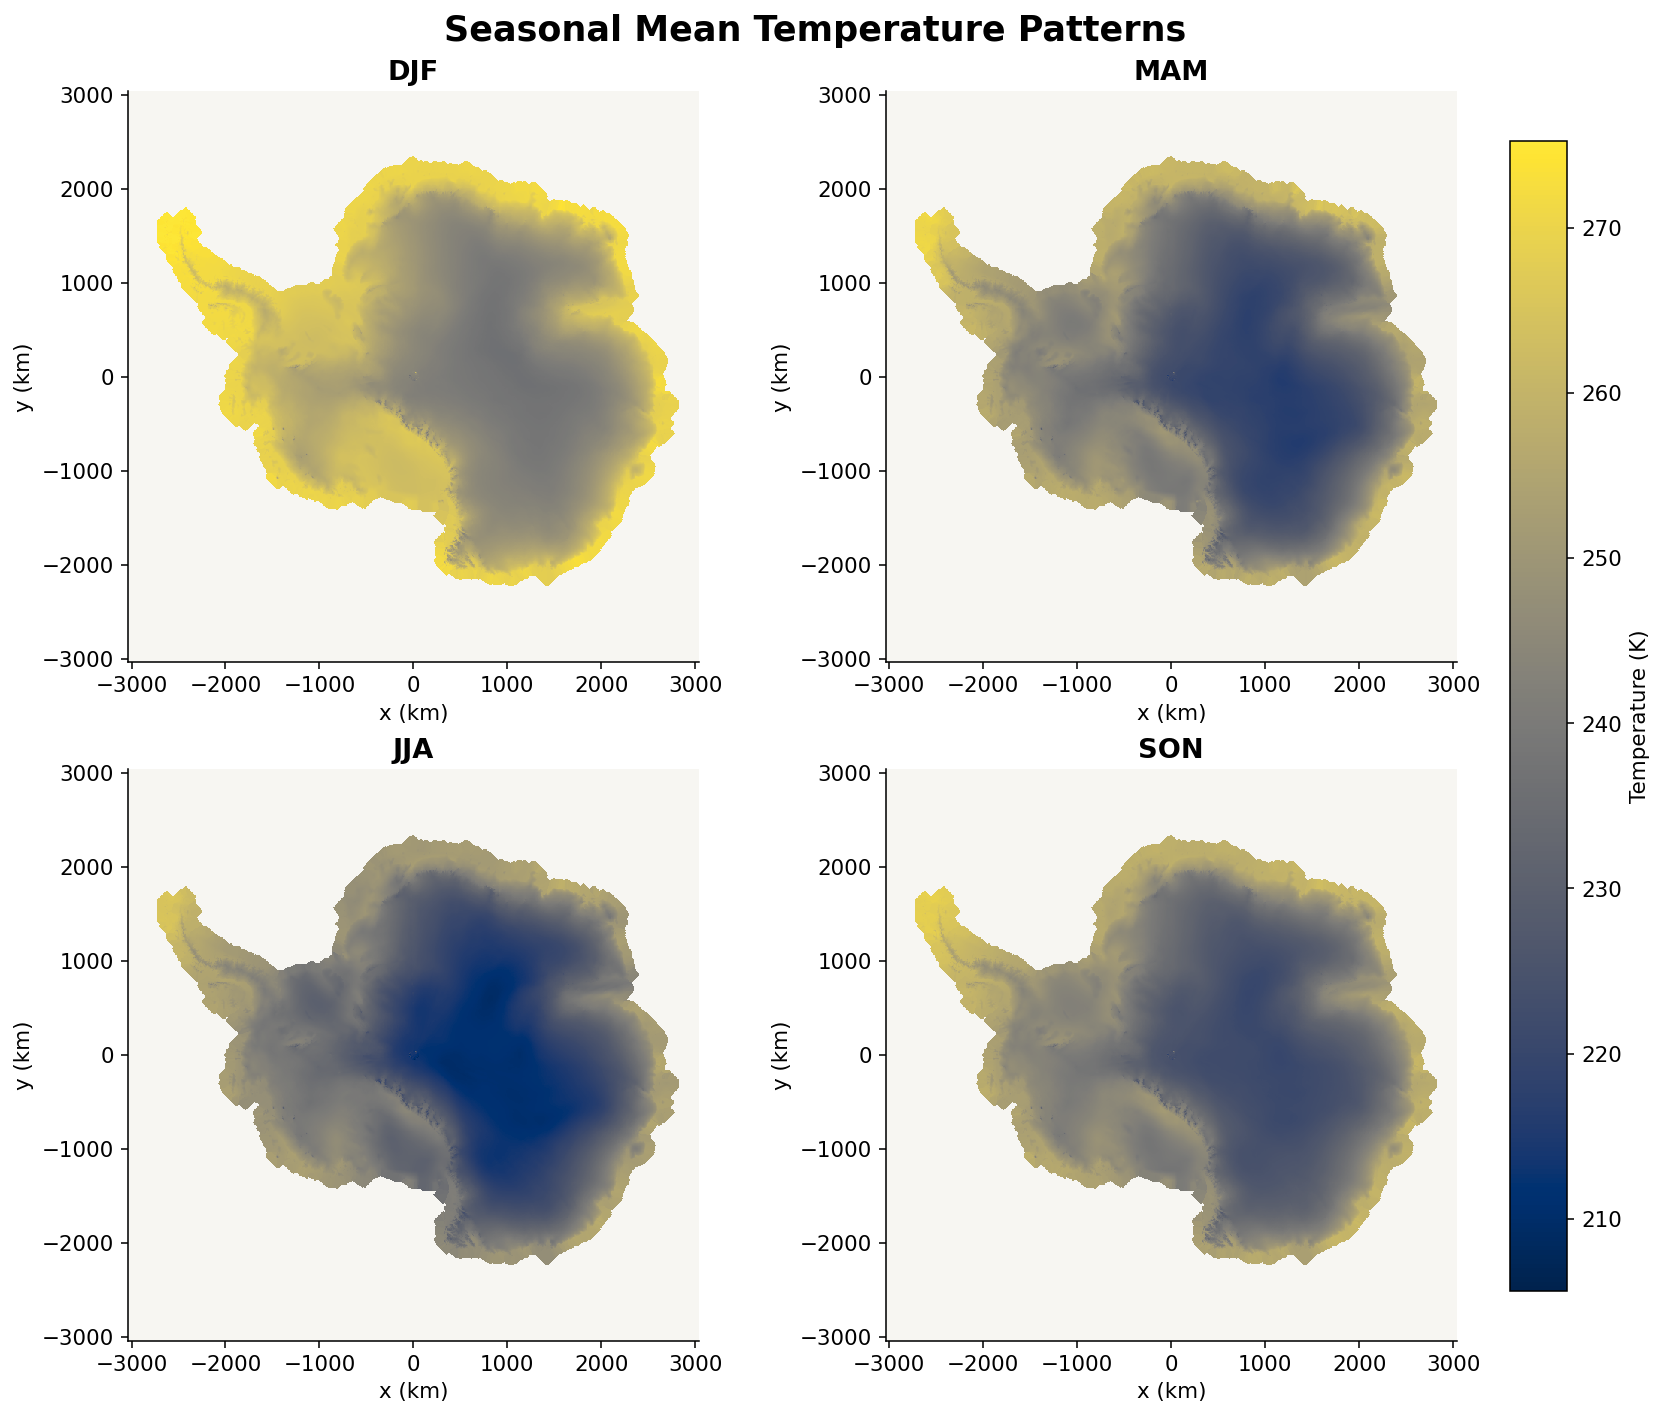

In [8]:
season_defs = {
    "DJF": [11, 0, 1],
    "MAM": [2, 3, 4],
    "JJA": [5, 6, 7],
    "SON": [8, 9, 10],
}

season_maps = {name: nanmean_stack(maps[idxs], axis=0) for name, idxs in season_defs.items()}
season_vmin = min(np.nanmin(arr) for arr in season_maps.values())
season_vmax = max(np.nanmax(arr) for arr in season_maps.values())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

for ax, (name, arr) in zip(axes.ravel(), season_maps.items()):
    im = ax.imshow(
        arr,
        origin="lower",
        extent=extent,
        cmap="cividis",
        vmin=season_vmin,
        vmax=season_vmax,
        interpolation="nearest",
    )
    ax.set_title(name)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")

cbar = fig.colorbar(im, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label("Temperature (K)")
fig.suptitle("Seasonal Mean Temperature Patterns", fontsize=18, fontweight="bold")
fig.savefig(FIG_DIR / "tas_seasonal_maps.png", bbox_inches="tight")
plt.show()


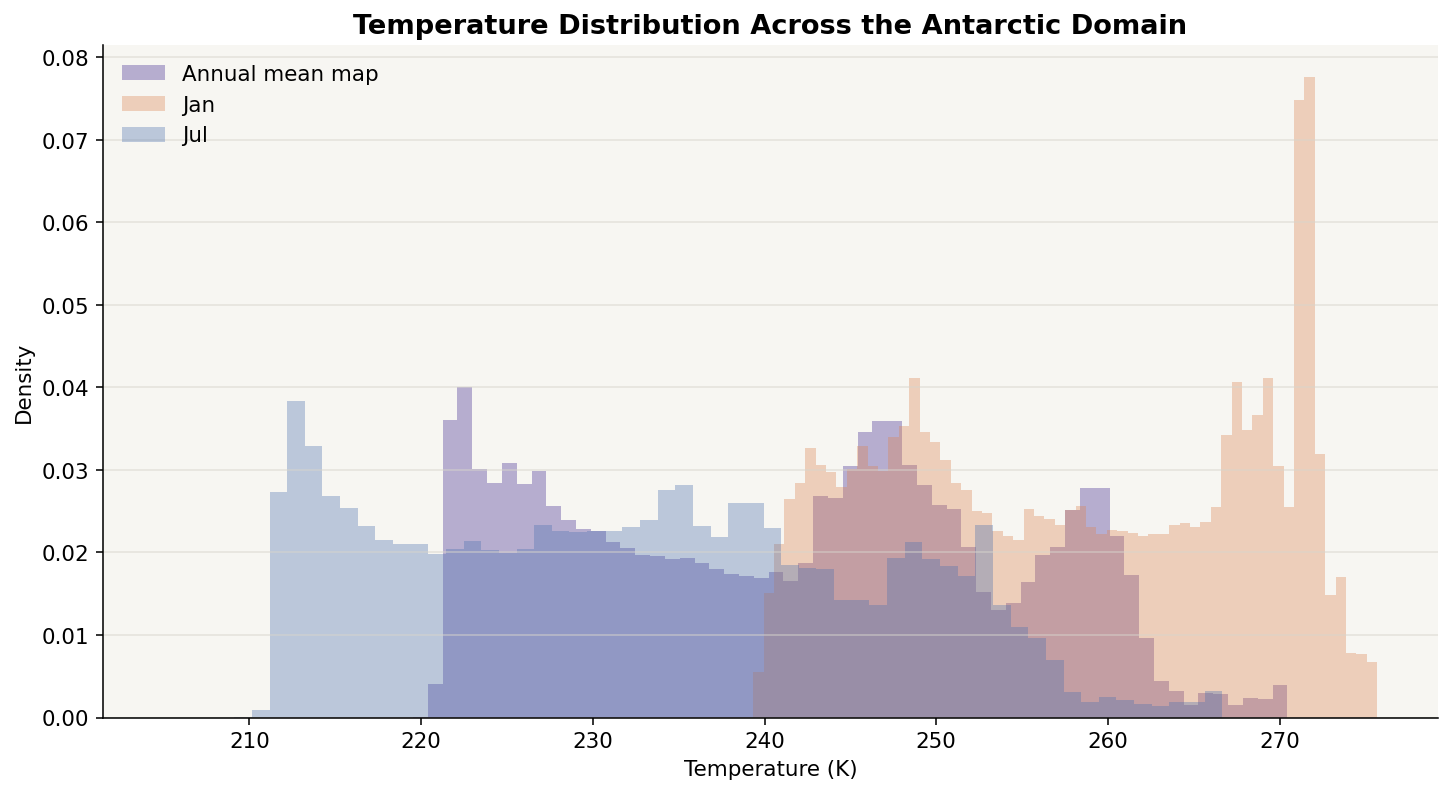

In [9]:
sample = annual_mean_map[np.isfinite(annual_mean_map)]
summer = maps[0][np.isfinite(maps[0])]
winter = maps[6][np.isfinite(maps[6])]

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.hist(sample, bins=60, density=True, alpha=0.55, color="#8172b3", label="Annual mean map")
ax.hist(summer, bins=60, density=True, alpha=0.35, color="#dd8452", label=time[0].strftime("%b"))
ax.hist(winter, bins=60, density=True, alpha=0.35, color="#4c72b0", label=time[6].strftime("%b"))
ax.set_title("Temperature Distribution Across the Antarctic Domain")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Density")
ax.grid(True, axis="y")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "tas_distribution.png", bbox_inches="tight")
plt.show()


## Quick interpretation

- The file stores **monthly mean 2 m air temperature** over Antarctica for **calendar year 2015**
- Values are on a **projected Cartesian grid**, so plotting against `x`/`y` is the most direct view
- The large square domain includes masked cells outside the valid forcing footprint, so masking the fill value is essential
- Seasonal structure should be visible as warmer austral-summer conditions and colder austral-winter conditions, with strong spatial gradients across the ice sheet and surrounding regions

If you want, the next natural extension would be to compare this file with another variable or another year/scenario from the ISMIP7 forcing set.
